This project is seeking to predict the severity of a car crash based on over 60 features. The car crash severity is as follows. O is given if there is no injury to the driver, C is given if there is no apparent injury, B is given if there is minor/possible injury, A is given if there is serious injuries (severe laceration, bone breaks, unconscious, paralysis, etc), and K is given if there is a death whether at the scene or within 30 days of the accident.

All good projects start with visualizing our data, we want to see what we are working with!

In [ ]:
# Import some common packages
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import scatter_matrix # optional
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# to make this notebook's output stable across runs
np.random.seed(42)

# Your code goes here for this section, make sure you also include the output to answer the above questions.

import pandas as pd

def load_crash_data(csv_filename = "Crash_Data.csv"):
  crash = pd.read_csv('Crash_Data.csv')
  return crash


crash = load_crash_data()
print(len(crash))
crash.head(10)


16831


,X,Y,OBJECTID,DOCUMENT_NBR,CRASH_YEAR,CRASH_DT,CRASH_MILITARY_TM,CRASH_SEVERITY,K_PEOPLE,A_PEOPLE,...,AREA_TYPE,SYSTEM,VSP,OWNERSHIP,PLAN_DISTRICT,MPO_NAME,RTE_NM,RNS_MP,NODE,OFFSET
0,-78.870556,38.645544,1,152915206,2015,2015/10/16 17:00:00+00,1700,A,0,2,...,Rural,VDOT Primary,2.0,1. State Hwy Agency,Central Shenandoah,NaN,R-VA SR00259SB,9.63,586049.0,834.0
1,-77.134973,38.943531,2,153060033,2015,2015/10/10 23:50:00+00,2350,O,0,0,...,Urban,NonVDOT secondary,7.0,4. Federal Roads,Northern Virginia,NOVA,R-VA OT90072NB,0.41,NaN,NaN
2,-79.499399,36.660702,3,153035144,2015,2015/10/29 11:23:59+00,1124,B,0,0,...,Rural,VDOT Secondary,6.0,1. State Hwy Agency,West Piedmont,NaN,R-VA071SC00750SB,5.90,518624.0,137.0
3,-77.336244,38.545770,4,150975078,2015,2015/04/06 09:00:00+00,900,O,0,0,...,Urban,VDOT Secondary,7.0,1. State Hwy Agency,Northern Virginia,NOVA,R-VA076SC00619EB,25.74,NaN,NaN
4,-79.337225,36.581073,5,152335159,2015,2015/08/21 07:50:59+00,751,O,0,0,...,Urban,NonVDOT primary,6.0,3. City or Town Hwy Agency,West Piedmont,DAN,R-VA US00058WB,301.27,519895.0,876.0
5,-78.113043,39.179699,6,151605030,2015,2015/06/04 22:20:00+00,2220,O,0,0,...,Urban,VDOT Secondary,2.0,1. State Hwy Agency,Northern Shenandoah Valley,WINC,R-VA034SC01290NB,0.02,706172.0,90.0
6,-78.098895,37.295460,7,150665275,2015,2015/03/01 14:19:59+00,1420,O,0,0,...,Rural,VDOT Primary,1.0,1. State Hwy Agency,Commonwealth Regional,NaN,R-VA US00360EB,97.39,120143.0,11.0
7,-80.909468,36.673844,8,151525334,2015,2015/06/01 13:38:59+00,1339,O,0,0,...,Urban,NonVDOT primary,4.0,3. City or Town Hwy Agency,Mount Rogers,NaN,R-VA US00058WB,191.12,189139.0,708.0
8,-79.842938,37.350047,9,152645164,2015,2015/09/18 17:39:59+00,1740,O,0,0,...,Urban,VDOT Secondary,6.0,1. State Hwy Agency,Roanoke Valley-Alleghany,ROAN,R-VA011SC01413SB,0.22,158264.0,1172.0
9,-79.968045,37.285888,10,152255158,2015,2015/08/06 21:36:00+00,2136,O,0,0,...,Urban,NonVDOT primary,6.0,3. City or Town Hwy Agency,Roanoke Valley-Alleghany,ROAN,R-VA US00460WB,153.63,573411.0,639.0


In [ ]:
crash.info()
crash.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16831 entries, 0 to 16830
Data columns (total 69 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   X                         16831 non-null  float64
 1   Y                         16831 non-null  float64
 2   OBJECTID                  16831 non-null  int64  
 3   DOCUMENT_NBR              16831 non-null  int64  
 4   CRASH_YEAR                16831 non-null  int64  
 5   CRASH_DT                  16831 non-null  object 
 6   CRASH_MILITARY_TM         16831 non-null  int64  
 7   CRASH_SEVERITY            16831 non-null  object 
 8   K_PEOPLE                  16831 non-null  int64  
 9   A_PEOPLE                  16831 non-null  int64  
 10  B_PEOPLE                  16831 non-null  int64  
 11  C_PEOPLE                  16831 non-null  int64  
 12  PERSONS_INJURED           16831 non-null  int64  
 13  PEDESTRIANS_KILLED        16831 non-null  int64  
 14  PEDEST

,0
X,0
Y,0
OBJECTID,0
DOCUMENT_NBR,0
CRASH_YEAR,0
...,...
MPO_NAME,3544
RTE_NM,1
RNS_MP,35
NODE,4120


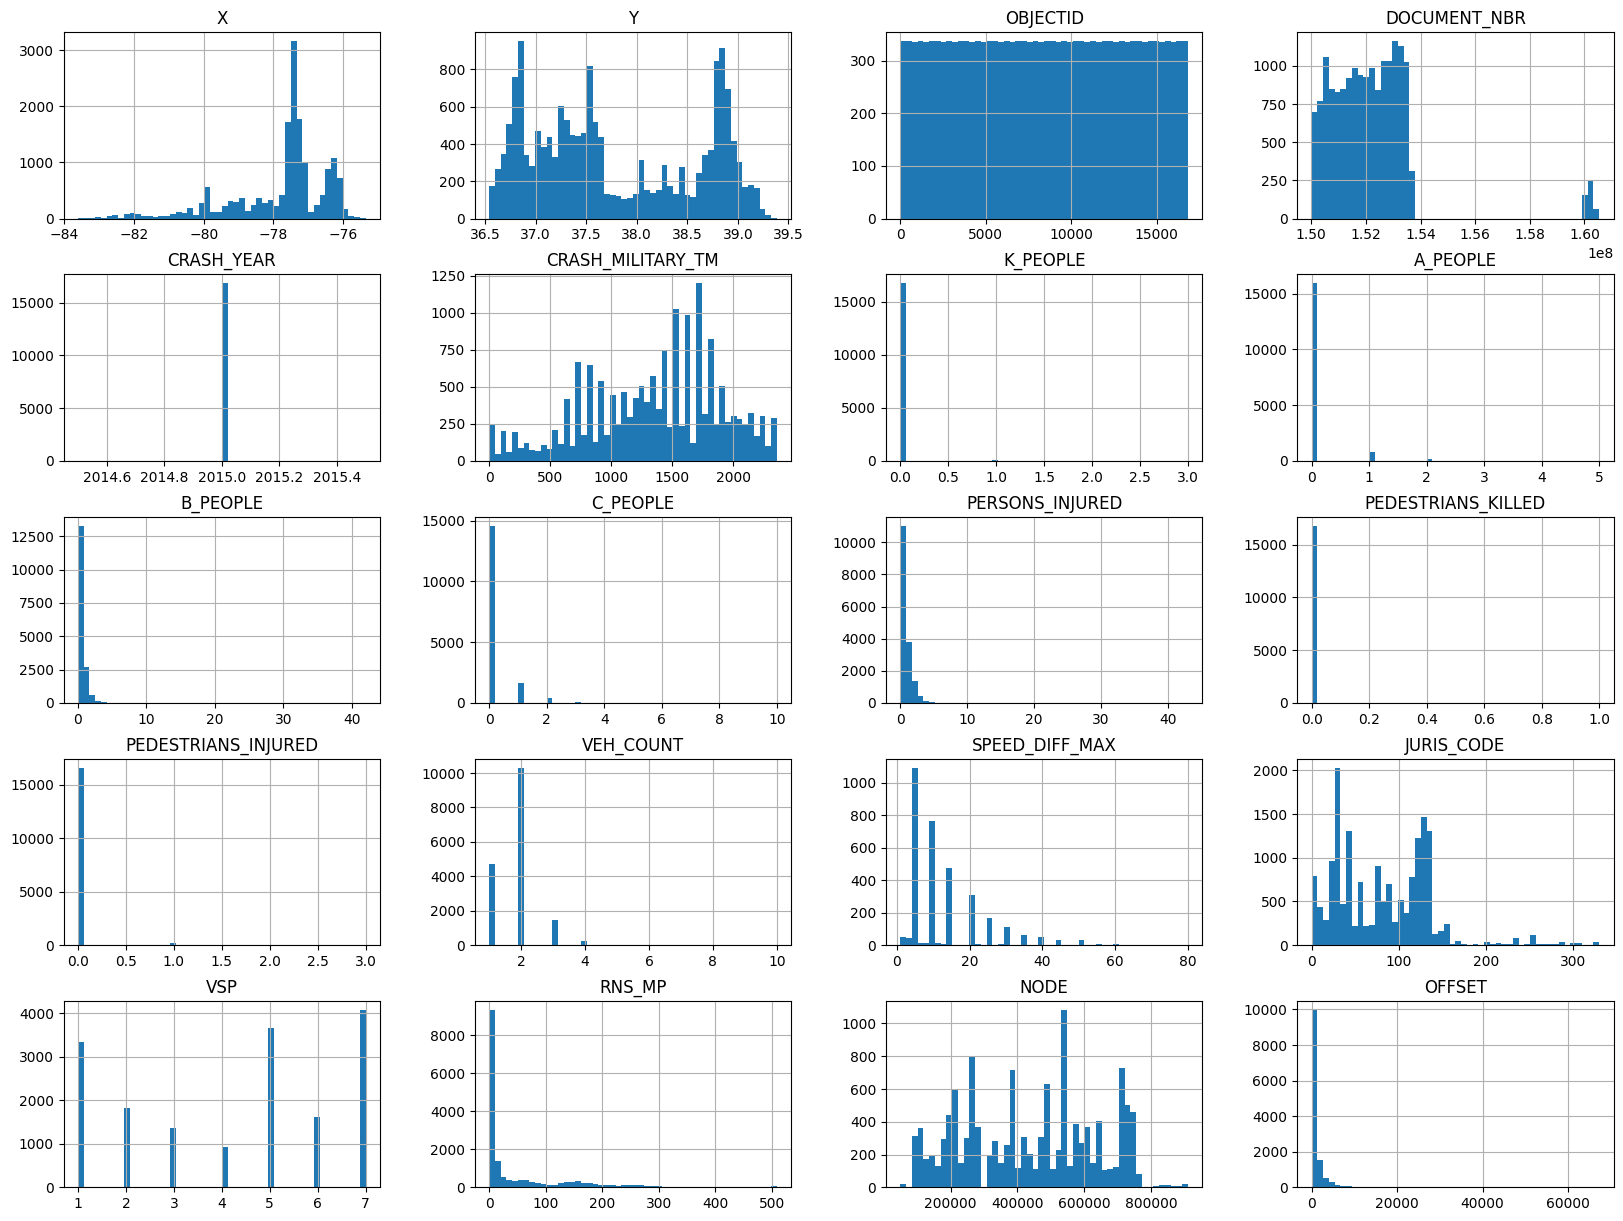

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
crash.hist(bins=50, figsize=(20,15))
plt.show()
#save_fig("attribute_histogram_plots")

Now it's time to clean and scale, we want to build out a pipeline that can prepare our current set as well as future data!

In [ ]:
# Compute correlation matrix
corr_matrix = crash.corr(numeric_only = True)

corr_matrix.shape

(20, 20)

In [ ]:
# Cleaning and Data Splitting

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Strip whitespace from column names
crash.columns = crash.columns.str.strip()

# Drop rows with missing target
crash = crash.dropna(subset=['CRASH_SEVERITY'])

# First, split out the test set (20% of the data)
train_val_set, test_set = train_test_split(crash, test_size=0.2, random_state=42)

# Then, split the remaining data into training and validation sets (e.g., 80% train, 20% validation)
train_set, validation_set = train_test_split(train_val_set, test_size=0.2, random_state=42)

# Separate the target from training and validation sets
train_labels = train_set['CRASH_SEVERITY'].copy()
train_set = train_set.drop('CRASH_SEVERITY', axis=1)

validation_labels = validation_set['CRASH_SEVERITY'].copy()
validation_set = validation_set.drop('CRASH_SEVERITY', axis=1)

test_labels = test_set['CRASH_SEVERITY'].copy()
test_set = test_set.drop('CRASH_SEVERITY', axis=1)

# (For final evaluation, you'll keep test_set unseen.
# When ready, you can extract test_labels similarly if needed:
# test_labels = test_set['CRASH_SEVERITY'].copy()
# test_set = test_set.drop('CRASH_SEVERITY', axis=1)
# But for now, assume test_set is untouched.)

# Identify numeric and categorical columns from the training set
numeric = train_set.select_dtypes(include=['float64', 'int64'])
categorical = train_set.select_dtypes(include=['object'])

num_attribs = list(numeric.columns)
cat_attribs = list(categorical.columns)

# Create a numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])

# Combine the pipelines for numeric and categorical features
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown='ignore', max_categories=50), cat_attribs)
])

# Fit the pipeline on the training set only, then transform training, validation, and test sets
train_prepared = full_pipeline.fit_transform(train_set)
validation_prepared = full_pipeline.transform(validation_set)
test_prepared = full_pipeline.transform(test_set)

# # Print the shapes to verify
print("Train prepared shape:", train_prepared.shape)
print("Validation prepared shape:", validation_prepared.shape)
print("Test prepared shape:", test_prepared.shape)

Train prepared shape: (10771, 469)
Validation prepared shape: (2693, 469)
Test prepared shape: (3367, 469)


Now that we have our full data pipeline we can now test potential models!

In [ ]:
# Extract test labels and remove them from test_set before transforming
# test_labels = test_set['CRASH_SEVERITY'].copy()
# test_set = test_set.drop('CRASH_SEVERITY', axis=1)
# test_prepared = full_pipeline.transform(test_set)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# pipeline = Pipeline([
#     ("preparation", full_pipeline),
#     ("model", RandomForestClassifier(random_state=42))
# ])

# param_grid = {
#     'model__n_estimators': [50, 100, 200],
#     'model__max_depth': [5, 10, 15, None],
#     'model__min_samples_split': [2, 5, 10],
#     'model__min_samples_leaf': [1, 3, 5],
#     'model__max_features': ['sqrt', 'log2'],
#     'model__class_weight': [None, 'balanced']
# }

# grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
# grid_search.fit(train_set, train_labels)
# predictions = grid_search.predict(test_set)
# print(classification_report(test_labels, predictions))

#Initialize and train the RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,            # limit the maximum depth of the trees
    min_samples_split=5,     # require at least 5 samples to split an internal node
    min_samples_leaf=3,      # require at least 3 samples to be at a leaf node
    max_features='sqrt',     # limit the number of features considered at each split
    random_state=42)
model.fit(train_prepared, train_labels)

# Predict on the prepared test set
predictions = model.predict(test_prepared)
print("Accuracy:", accuracy_score(test_labels, predictions))

# Evaluate the model's performance
print(classification_report(test_labels, predictions))

Accuracy: 0.9869319869319869
              precision    recall  f1-score   support

           A       0.97      0.90      0.94       170
           B       0.98      1.00      0.99       651
           C       0.99      0.98      0.98       316
           K       0.00      0.00      0.00        21
           O       0.99      1.00      1.00      2209

    accuracy                           0.99      3367
   macro avg       0.79      0.78      0.78      3367
weighted avg       0.98      0.99      0.98      3367



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


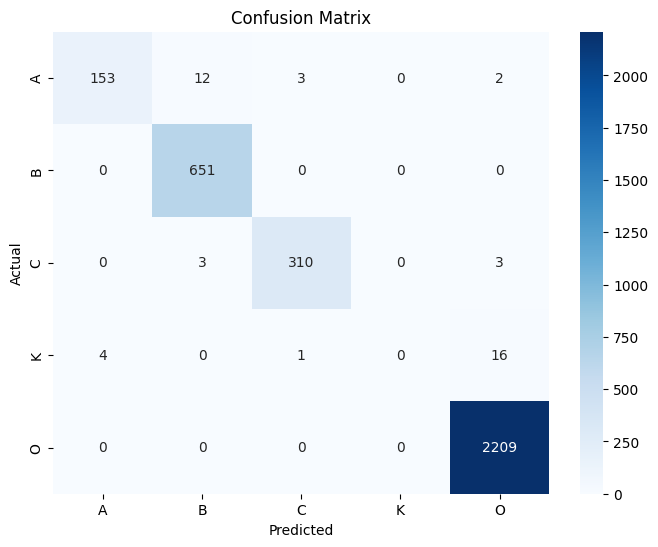

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(test_labels),
            yticklabels=np.unique(test_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
overlap = set(train_set.index).intersection(set(validation_set.index))
print("Overlap between train and validation indices:", overlap)


Overlap between train and validation indices: set()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9944300037133309
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       149
           B       1.00      0.98      0.99       566
           C       0.95      1.00      0.97       235
           K       1.00      0.94      0.97        17
           O       1.00      1.00      1.00      1726

    accuracy                           0.99      2693
   macro avg       0.99      0.98      0.98      2693
weighted avg       0.99      0.99      0.99      2693



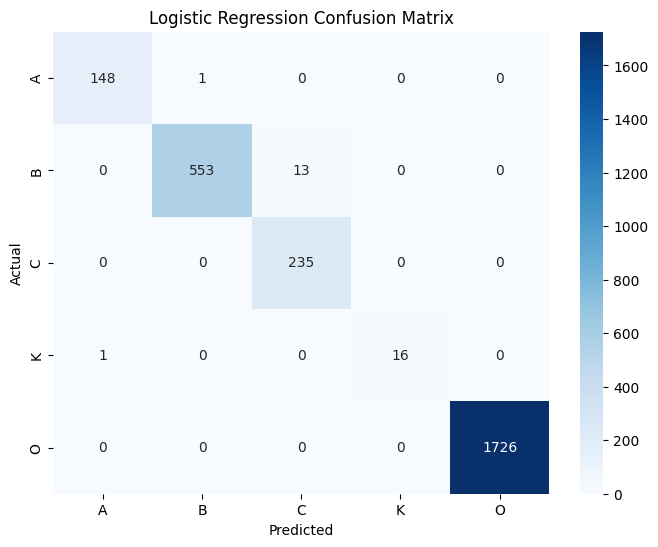

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
log_reg = LogisticRegression(multi_class='multinomial',
    solver='lbfgs',
    max_iter=500,
    C=0.01,             # Adjust C to control regularization strength
    penalty='l2',       # Regularization penalty (l2 is default for lbfgs)
    class_weight='balanced')  # Use this if your classes are imbalanced)

log_reg.fit(train_prepared, train_labels)

# pipeline = Pipeline([
#     ("preprocessing", full_pipeline),  # If you haven't already transformed your data
#     ("model", LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500))
# ])

# param_grid = {
#     "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],  # range of regularization strengths
#     "model__class_weight": [None, "balanced"]
# }

# grid_search = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=5,  # 5-fold cross validation
#     scoring="f1_weighted",
#     n_jobs=-1
# )

# grid_search.fit(train_set, train_labels)  # pass raw features; pipeline handles transformation
# best_model = grid_search.best_estimator_

# Predict on test set
# log_predictions = log_reg.predict(test_prepared)

# Evaluate
log_predictions = log_reg.predict(validation_prepared)

print("Accuracy:", accuracy_score(validation_labels, log_predictions))
print(classification_report(validation_labels, log_predictions))



# Confusion Matrix
cm = confusion_matrix(validation_labels, log_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(validation_labels),
            yticklabels=np.unique(validation_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


Number of duplicate rows: 0
Train prepared shape: (39133, 510)
Validation prepared shape: (9784, 510)
Test prepared shape: (12230, 510)
Validation Set Classification Report:
              precision    recall  f1-score   support

           A       0.73      0.85      0.79       512
           B       0.98      0.92      0.95      1914
           C       0.96      0.96      0.96       930
           K       0.44      1.00      0.61        54
           O       1.00      0.99      1.00      6374

    accuracy                           0.97      9784
   macro avg       0.82      0.95      0.86      9784
weighted avg       0.97      0.97      0.97      9784



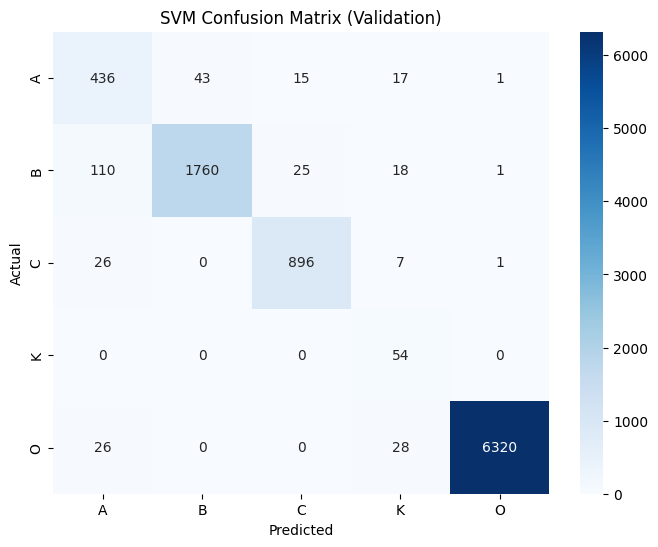

Test Set Classification Report:
              precision    recall  f1-score   support

           A       0.72      0.86      0.78       640
           B       0.98      0.91      0.94      2392
           C       0.95      0.95      0.95      1163
           K       0.39      1.00      0.56        68
           O       1.00      0.99      0.99      7967

    accuracy                           0.96     12230
   macro avg       0.81      0.94      0.85     12230
weighted avg       0.97      0.96      0.97     12230



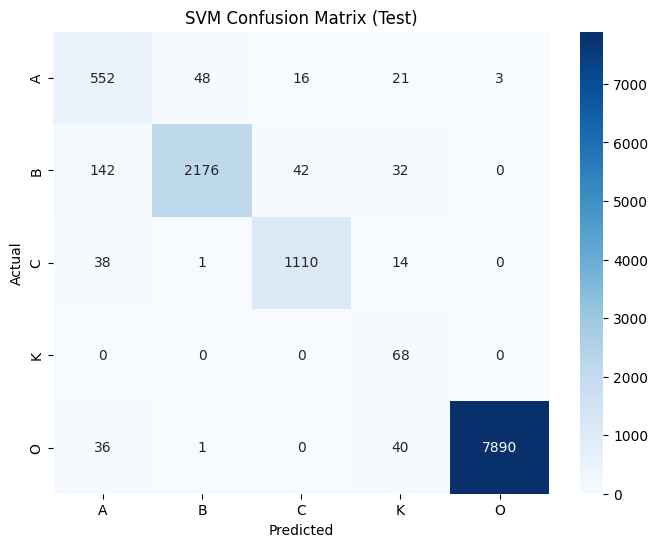

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier

# ----- Data Loading and Cleaning -----
def load_crash_data(csv_filename="Crash_Data.csv"):
    crash = pd.read_csv(csv_filename, engine='python', on_bad_lines='skip')
    crash.columns = crash.columns.str.strip()
    crash = crash.dropna(subset=['CRASH_SEVERITY'])
    return crash

crash = load_crash_data()

# Check for duplicates
duplicate_count = crash.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# ----- Data Splitting -----
# Split out the test set (20%) using stratification on the target
train_val_set, test_set = train_test_split(crash, test_size=0.2, random_state=42, stratify=crash['CRASH_SEVERITY'])
# Split train_val_set into training (80%) and validation (20%)
train_set, validation_set = train_test_split(train_val_set, test_size=0.2, random_state=42, stratify=train_val_set['CRASH_SEVERITY'])

# Separate target from features
train_labels = train_set['CRASH_SEVERITY'].copy()
train_set = train_set.drop('CRASH_SEVERITY', axis=1)

validation_labels = validation_set['CRASH_SEVERITY'].copy()
validation_set = validation_set.drop('CRASH_SEVERITY', axis=1)

test_labels = test_set['CRASH_SEVERITY'].copy()
test_set = test_set.drop('CRASH_SEVERITY', axis=1)

# ----- Preprocessing Pipeline -----
# Identify numeric and categorical columns
numeric = train_set.select_dtypes(include=['float64', 'int64'])
categorical = train_set.select_dtypes(include=['object'])

num_attribs = list(numeric.columns)
cat_attribs = list(categorical.columns)

# Numeric pipeline: imputation and scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Full pipeline combining numeric and categorical processing
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown='ignore', max_categories=50), cat_attribs)
])

# Fit the pipeline on the training set only, then transform training, validation, and test sets
train_prepared = full_pipeline.fit_transform(train_set)
validation_prepared = full_pipeline.transform(validation_set)
test_prepared = full_pipeline.transform(test_set)

# # Print the shapes to verify
print("Train prepared shape:", train_prepared.shape)
print("Validation prepared shape:", validation_prepared.shape)
print("Test prepared shape:", test_prepared.shape)

# ----- PCA and SVM Pipeline -----
# Optionally reduce dimensionality with PCA to speed up SVM training
pca = PCA(n_components=20)

# Create a pipeline that includes preprocessing, PCA, and the SVM classifier
model_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('pca', pca),
    ('nystroem', Nystroem(kernel='rbf', n_components=100, random_state=42)),
    ('sgd', SGDClassifier(loss='hinge', class_weight='balanced', max_iter=1000, tol=1e-3))
])

# ----- Train the Model -----
model_pipeline.fit(train_set, train_labels)

# ----- Evaluate on the Validation Set -----
val_predictions = model_pipeline.predict(validation_set)
print("Validation Set Classification Report:")
print(classification_report(validation_labels, val_predictions))

cm_val = confusion_matrix(validation_labels, val_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(validation_labels),
            yticklabels=np.unique(validation_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix (Validation)')
plt.show()

# ----- Evaluate on the Test Set -----
test_predictions = model_pipeline.predict(test_set)
print("Test Set Classification Report:")
print(classification_report(test_labels, test_predictions))

cm_test = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(test_labels),
            yticklabels=np.unique(test_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix (Test)')
plt.show()

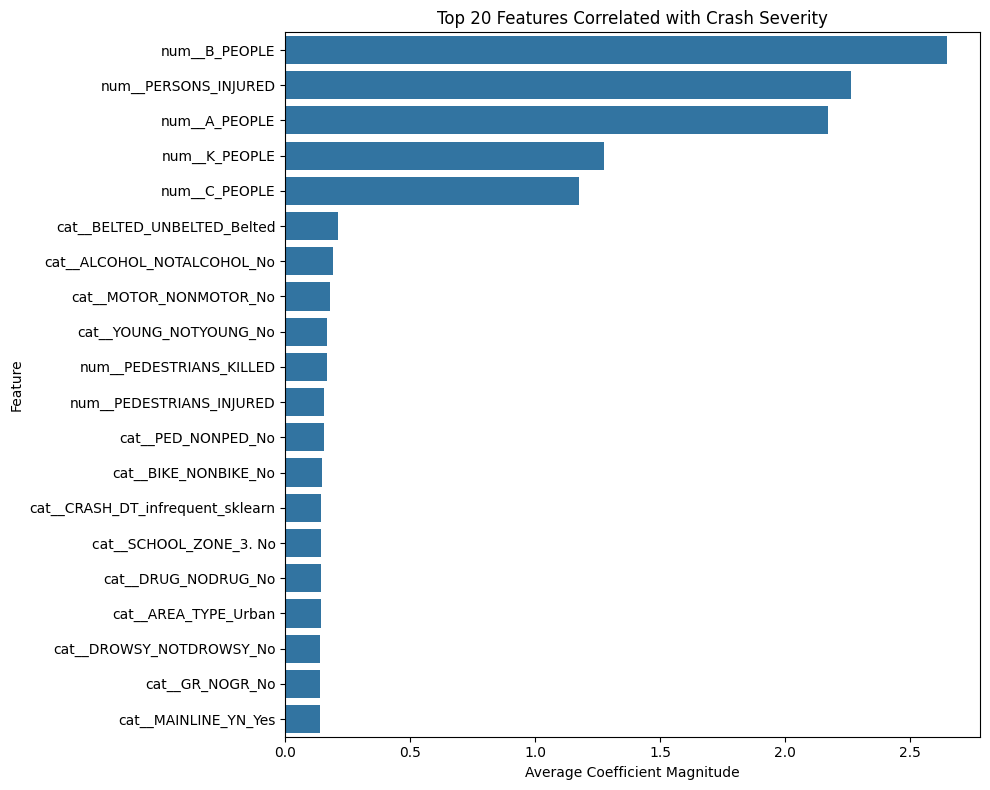


Top 50 features:
                                                      Feature  Importance
                                                num__B_PEOPLE    2.646267
                                         num__PERSONS_INJURED    2.263908
                                                num__A_PEOPLE    2.172200
                                                num__K_PEOPLE    1.273784
                                                num__C_PEOPLE    1.174740
                                  cat__BELTED_UNBELTED_Belted    0.212855
                                   cat__ALCOHOL_NOTALCOHOL_No    0.192261
                                       cat__MOTOR_NONMOTOR_No    0.177230
                                       cat__YOUNG_NOTYOUNG_No    0.168803
                                      num__PEDESTRIANS_KILLED    0.166774
                                     num__PEDESTRIANS_INJURED    0.156618
                                           cat__PED_NONPED_No    0.152901
                    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Train a Linear Model for Interpretability -----
# Replace SVM with Logistic Regression for feature importance
interpretable_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit the model
interpretable_pipeline.fit(train_set, train_labels)

# ----- Extract Feature Importances -----
# Get feature names after encoding and scaling
feature_names = interpretable_pipeline.named_steps['preprocessing'].get_feature_names_out()

# Get model coefficients (for multiclass: one row per class)
coef_matrix = interpretable_pipeline.named_steps['classifier'].coef_

# Compute average absolute importance across all classes
importance = np.abs(coef_matrix).mean(axis=0)

# Create a dataframe to sort and visualize
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Display top 20 features
top_k = 20
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances.head(top_k), x='Importance', y='Feature')
plt.title(f'Top {top_k} Features Correlated with Crash Severity')
plt.xlabel('Average Coefficient Magnitude')
plt.tight_layout()
plt.show()

# Optionally print the full ranked list
print("\nTop 50 features:")
print(feature_importances.head(50).to_string(index=False))

In [ ]:
duplicate_rows = crash.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)


Number of duplicate rows: 0


In [ ]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train_prepared, train_labels)
dummy_preds = dummy.predict(validation_prepared)
print(classification_report(validation_labels, dummy_preds))


              precision    recall  f1-score   support

           A       0.00      0.00      0.00       512
           B       0.00      0.00      0.00      1914
           C       0.00      0.00      0.00       930
           K       0.00      0.00      0.00        54
           O       0.65      1.00      0.79      6374

    accuracy                           0.65      9784
   macro avg       0.13      0.20      0.16      9784
weighted avg       0.42      0.65      0.51      9784



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
